### Dependencies

In [91]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np

### Load Raw Data

In [92]:
# === Load Raw Data ===
ambient_vib_pcb = np.load("ambient_vib_pcb.npy")
ambient_vib_wsn = np.load("ambient_vib_wsn.npy")
free_vib_pcb = np.load("free_vib_pcb.npy")
free_vib_wsn = np.load("free_vib_wsn.npy")

# === Transform Function: Convert PCB to WSN-Aligned Coordinate System ===
def transform_pcb_to_wsn(pcb_data):
    transformed = np.empty_like(pcb_data)
    for sensor_index in range(4):
        base = sensor_index * 3
        pcb_x = pcb_data[:, base + 0]
        pcb_y = pcb_data[:, base + 1]
        pcb_z = pcb_data[:, base + 2]

        # Coordinate transformation:
        # WSN_X = -PCB_Y
        # WSN_Y =  PCB_X
        # WSN_Z =  PCB_Z
        transformed[:, base + 0] = -pcb_y  # WSN X
        transformed[:, base + 1] =  pcb_x  # WSN Y
        transformed[:, base + 2] =  pcb_z  # WSN Z
    return transformed

# === Generate Aligned Versions ===
am_pcb_aligned   = transform_pcb_to_wsn(ambient_vib_pcb)
am_wsn_aligned   = ambient_vib_wsn.copy()

free_pcb_aligned = transform_pcb_to_wsn(free_vib_pcb)
free_wsn_aligned = free_vib_wsn.copy()

# === (Optional) Confirm Shapes Match ===
print("am_pcb_aligned:   ", am_pcb_aligned.shape)
print("am_wsn_aligned:   ", am_wsn_aligned.shape)
print("free_pcb_aligned: ", free_pcb_aligned.shape)
print("free_wsn_aligned: ", free_wsn_aligned.shape)


am_pcb_aligned:    (614400, 12)
am_wsn_aligned:    (41999, 12)
free_pcb_aligned:  (368640, 12)
free_wsn_aligned:  (17999, 12)


### Plot Raw Data

#### - Ambient Vibration

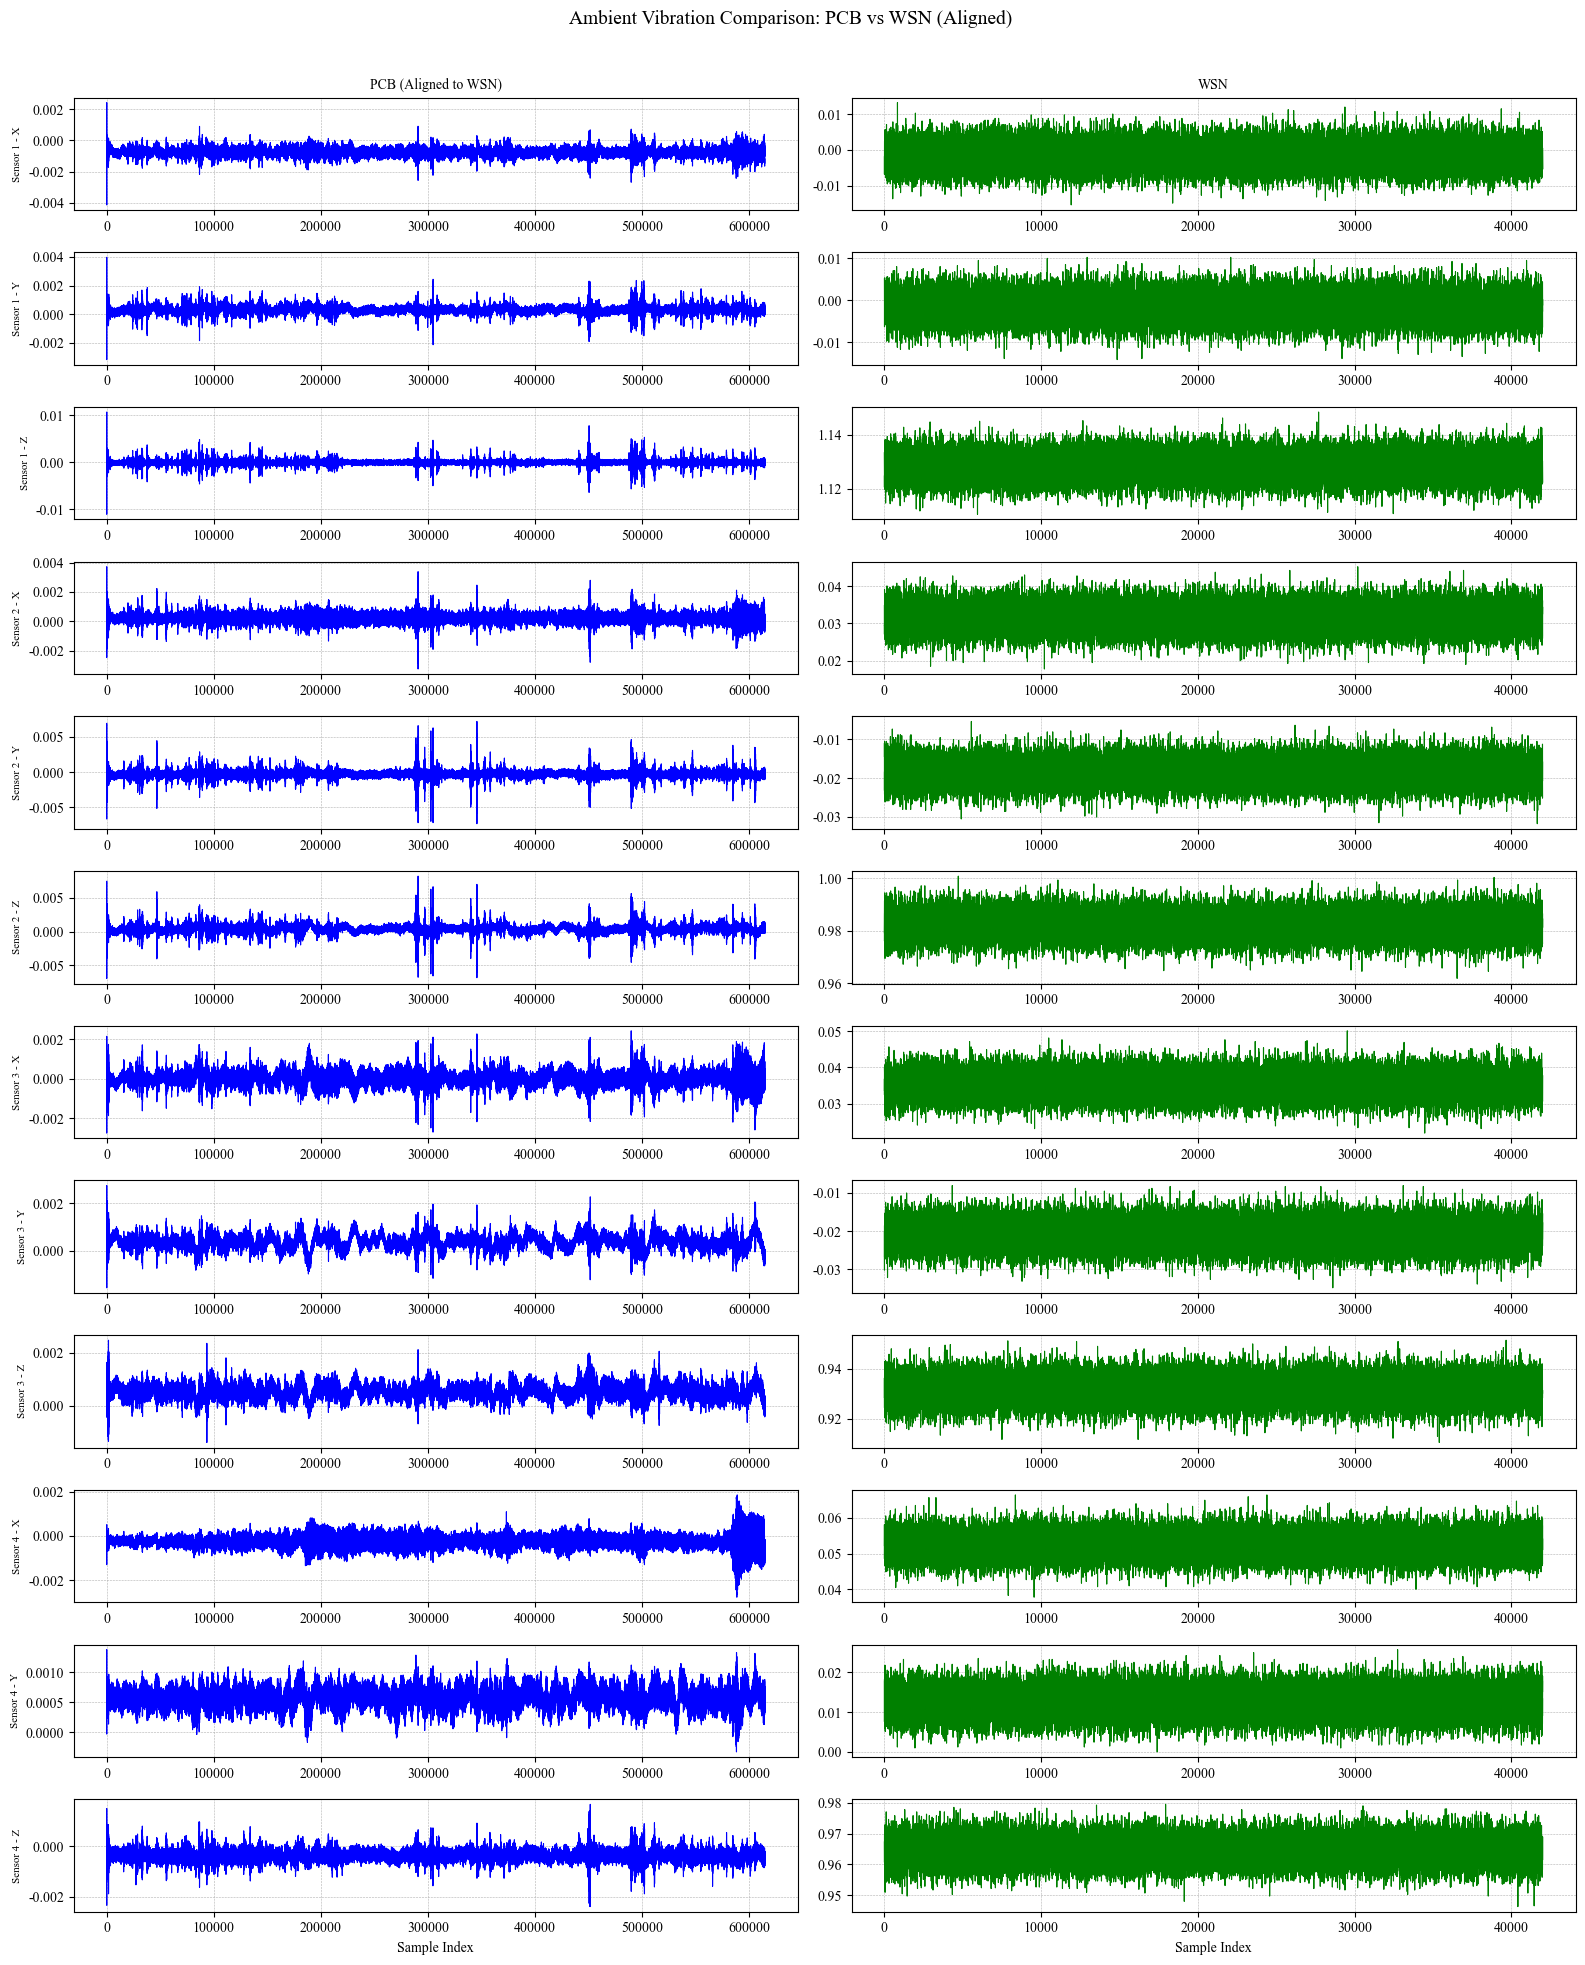

In [93]:
# === Time Axes (independent) ===
time_pcb_am = np.arange(am_pcb_aligned.shape[0])
time_wsn_am = np.arange(am_wsn_aligned.shape[0])

# === Channel Labels ===
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

# === Plot ===
fig, axes = plt.subplots(12, 2, figsize=(16, 20), sharex=False)

for i in range(12):
    # Left: PCB (Aligned)
    axes[i, 0].plot(time_pcb_am, am_pcb_aligned[:, i], color='blue', linewidth=0.8)
    axes[i, 0].set_ylabel(channel_labels[i], fontsize=8)
    axes[i, 0].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 0].set_title("PCB (Aligned to WSN)", fontsize=10)

    # Right: WSN
    axes[i, 1].plot(time_wsn_am, am_wsn_aligned[:, i], color='green', linewidth=0.8)
    axes[i, 1].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 1].set_title("WSN", fontsize=10)

axes[-1, 0].set_xlabel("Sample Index", fontsize=10)
axes[-1, 1].set_xlabel("Sample Index", fontsize=10)

fig.suptitle("Ambient Vibration Comparison: PCB vs WSN (Aligned)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


#### - Free Vibration

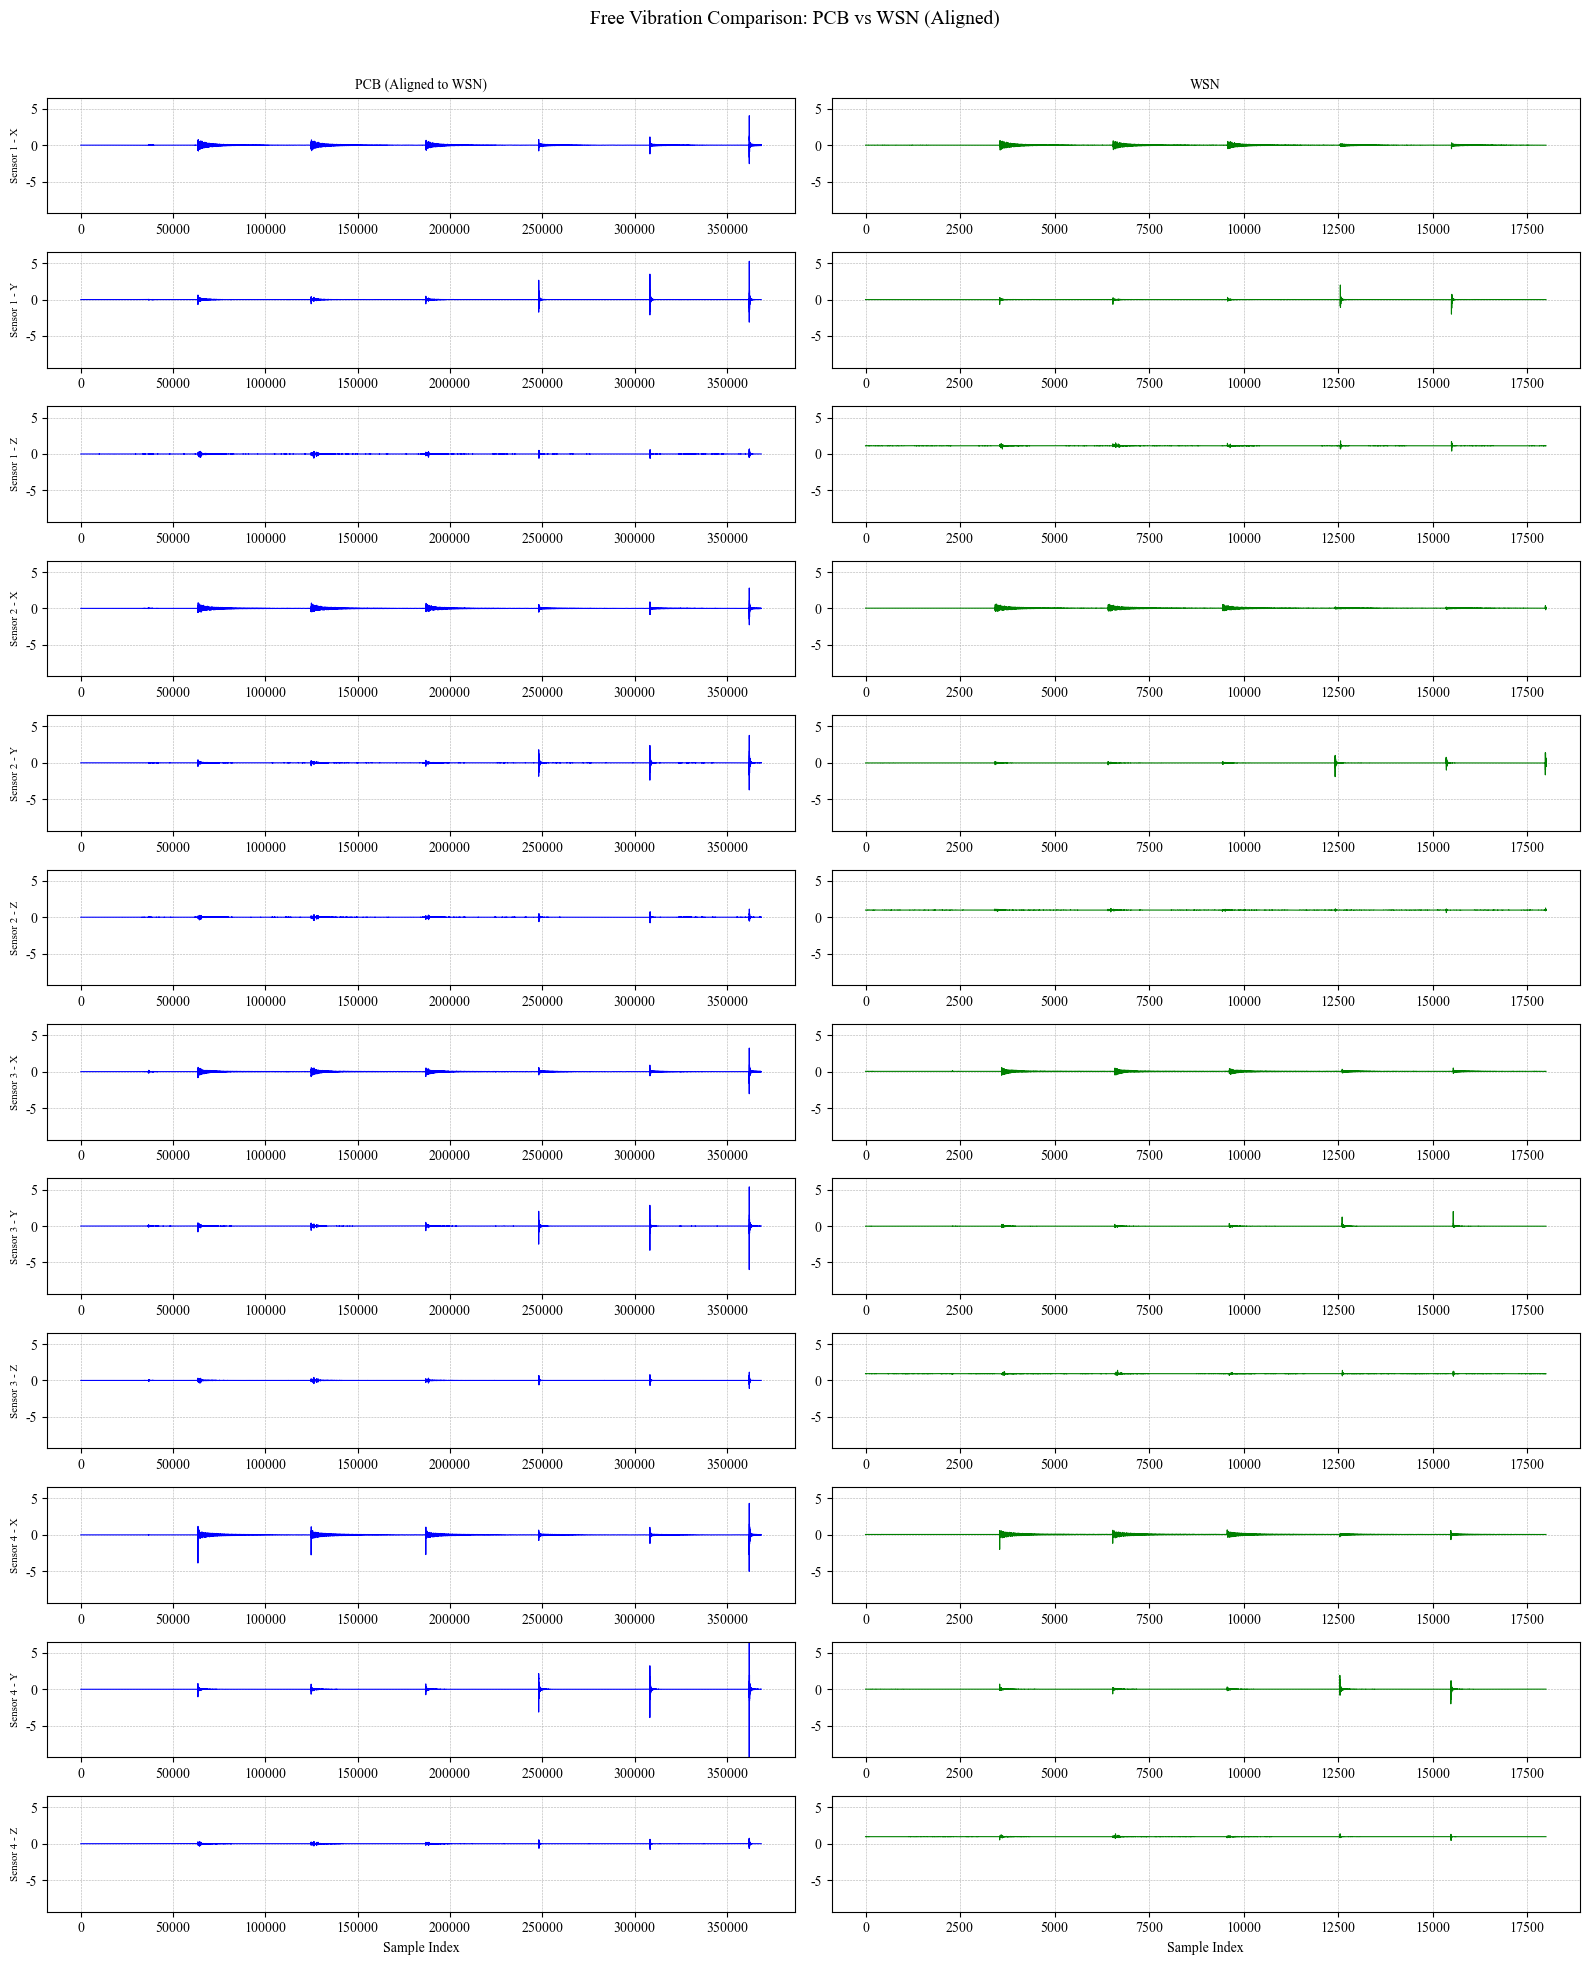

In [94]:
# === Font Settings ===
rcParams['font.family'] = 'Times New Roman'
rcParams['axes.unicode_minus'] = False

# === Time Axes (independent) ===
time_pcb = np.arange(free_pcb_aligned.shape[0])
time_wsn = np.arange(free_wsn_aligned.shape[0])

# === Channel Labels ===
channel_labels = [
    "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
    "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
    "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
    "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
]

# === Global Y Axis Range for Consistency ===
y_min = min(free_pcb_aligned.min(), free_wsn_aligned.min())
y_max = max(free_pcb_aligned.max(), free_wsn_aligned.max())

# === Plot ===
fig, axes = plt.subplots(12, 2, figsize=(16, 20), sharex=False)

for i in range(12):
    # Left: PCB
    axes[i, 0].plot(time_pcb, free_pcb_aligned[:, i], color='blue', linewidth=0.8)
    axes[i, 0].set_ylabel(channel_labels[i], fontsize=8)
    axes[i, 0].set_ylim(y_min, y_max)
    axes[i, 0].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 0].set_title("PCB (Aligned to WSN)", fontsize=10)

    # Right: WSN
    axes[i, 1].plot(time_wsn, free_wsn_aligned[:, i], color='green', linewidth=0.8)
    axes[i, 1].set_ylim(y_min, y_max)
    axes[i, 1].grid(True, linestyle='--', linewidth=0.4)
    if i == 0:
        axes[i, 1].set_title("WSN", fontsize=10)

axes[-1, 0].set_xlabel("Sample Index", fontsize=10)
axes[-1, 1].set_xlabel("Sample Index", fontsize=10)

fig.suptitle("Free Vibration Comparison: PCB vs WSN (Aligned)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### Data Processing - Detrending and Demeaning

In [95]:
from scipy.signal import detrend

def preprocess(data):
    """
    Preprocess data by:
    1. Removing linear trend.
    2. Removing column-wise mean.
    """
    data_detrended = detrend(data, axis=0)
    data_zero_mean = data_detrended - np.mean(data_detrended, axis=0)
    return data_zero_mean


In [96]:
am_pcb_processed   = preprocess(am_pcb_aligned)
am_wsn_processed   = preprocess(am_wsn_aligned)
free_pcb_processed = preprocess(free_pcb_aligned)
free_wsn_processed = preprocess(free_wsn_aligned)

print("Processed Ambient PCB Shape:   ", am_pcb_processed.shape)
print("Processed Ambient WSN Shape:   ", am_wsn_processed.shape)
print("Processed Free PCB Shape:     ", free_pcb_processed.shape)
print("Processed Free WSN Shape:     ", free_wsn_processed.shape)


Processed Ambient PCB Shape:    (614400, 12)
Processed Ambient WSN Shape:    (41999, 12)
Processed Free PCB Shape:      (368640, 12)
Processed Free WSN Shape:      (17999, 12)


In [97]:
from scipy.signal import resample_poly

def downsample_signal(signal, orig_fs, target_fs):
    """
    Downsample a multi-channel signal to target_fs using polyphase filtering.
    
    Parameters:
        signal     : np.ndarray of shape (N, C) - N samples, C channels
        orig_fs    : original sampling frequency
        target_fs  : target sampling frequency (must be lower than orig_fs)
        
    Returns:
        np.ndarray of shape (M, C) - downsampled signal
    """
    if target_fs >= orig_fs:
        raise ValueError("Target sampling frequency must be less than original sampling frequency.")

    # Compute integer factors
    from math import gcd
    g = gcd(orig_fs, target_fs)
    up = target_fs // g
    down = orig_fs // g

    # Apply resample_poly on each column
    channels = []
    for i in range(signal.shape[1]):
        ch = resample_poly(signal[:, i], up, down)
        channels.append(ch)

    # Stack back to array
    return np.stack(channels, axis=1)


In [98]:
# Sampling rates
FS_PCB = 2048
FS_WSN = 100

# Apply downsampling
am_pcb_downsampled   = downsample_signal(am_pcb_processed, FS_PCB, FS_WSN)
free_pcb_downsampled = downsample_signal(free_pcb_processed, FS_PCB, FS_WSN)

# Check shapes
print("Downsampled Ambient PCB shape:", am_pcb_downsampled.shape)
print("Downsampled Free PCB shape:", free_pcb_downsampled.shape)


Downsampled Ambient PCB shape: (30000, 12)
Downsampled Free PCB shape: (18000, 12)


In [99]:
def normalize_signal(signal):
    """
    Normalize each column (channel) using Z-score normalization.
    Output has zero mean and unit variance per channel.
    """
    mean = np.mean(signal, axis=0)
    std = np.std(signal, axis=0)
    std[std == 0] = 1  # avoid division by zero
    return (signal - mean) / std


In [100]:
# normalize the data before time sync

am_pcb_normalized   = normalize_signal(am_pcb_downsampled)
am_wsn_normalized   = normalize_signal(am_wsn_processed)
free_pcb_normalized = normalize_signal(free_pcb_downsampled)
free_wsn_normalized = normalize_signal(free_wsn_processed)

# check shapes
print("Normalized Ambient PCB shape:", am_pcb_normalized.shape)
print("Normalized Ambient WSN shape:", am_wsn_normalized.shape)
print("Normalized Free PCB shape:", free_pcb_normalized.shape)
print("Normalized Free WSN shape:", free_wsn_normalized.shape)


Normalized Ambient PCB shape: (30000, 12)
Normalized Ambient WSN shape: (41999, 12)
Normalized Free PCB shape: (18000, 12)
Normalized Free WSN shape: (17999, 12)


In [101]:
def compute_energy_signals(signal_12ch):
    """
    Combine every 3 channels (X, Y, Z) of each sensor into a single energy signal (x^2 + y^2 + z^2).
    Input:  signal_12ch: shape (N, 12)
    Output: signal_combined: shape (N, 4)
    """
    N = signal_12ch.shape[0]
    signal_combined = np.zeros((N, 4))

    for sensor_idx in range(4):
        base = sensor_idx * 3
        x = signal_12ch[:, base + 0]
        y = signal_12ch[:, base + 1]
        z = signal_12ch[:, base + 2]
        signal_combined[:, sensor_idx] = x**2 + y**2 + z**2

    return signal_combined

am_pcb_energy   = compute_energy_signals(am_pcb_normalized)
am_wsn_energy   = compute_energy_signals(am_wsn_normalized)
free_pcb_energy = compute_energy_signals(free_pcb_normalized)
free_wsn_energy = compute_energy_signals(free_wsn_normalized)

print("Ambient PCB Energy shape:   ", am_pcb_energy.shape)
print("Ambient WSN Energy shape:   ", am_wsn_energy.shape)
print("Free PCB Energy shape:     ", free_pcb_energy.shape)
print("Free WSN Energy shape:     ", free_wsn_energy.shape)


Ambient PCB Energy shape:    (30000, 4)
Ambient WSN Energy shape:    (41999, 4)
Free PCB Energy shape:      (18000, 4)
Free WSN Energy shape:      (17999, 4)


In [102]:
from scipy.signal import correlate, correlation_lags

def compute_lags(pcb_energy, wsn_energy, trim_ratio=0.1):
    """
    Compute lag (in samples) indicating how much WSN lags behind PCB.

    Parameters:
        pcb_energy: np.ndarray, shape (N, 4)
        wsn_energy: np.ndarray, shape (N, 4)
        trim_ratio: float, fraction to trim from start and end (e.g., 0.1 means drop 10%)

    Returns:
        List of lags (one per sensor). Positive means WSN lags behind PCB.
    """
    lags = []
    N = pcb_energy.shape[0]
    start = int(N * trim_ratio)
    end = int(N * (1 - trim_ratio))

    for i in range(4):  # For 4 sensors
        pcb = pcb_energy[start:end, i]
        wsn = wsn_energy[start:end, i]

        # Compute cross-correlation with WSN relative to PCB
        corr = correlate(wsn, pcb, mode='full')
        lag_arr = correlation_lags(len(wsn), len(pcb), mode='full')
        lag = lag_arr[np.argmax(corr)]
        lags.append(lag)

    return lags

# === Compute trimmed lags ===
lag_ambient = compute_lags(am_pcb_energy, am_wsn_energy)
lag_free    = compute_lags(free_pcb_energy, free_wsn_energy)

print("Ambient Lags (WSN behind PCB):", lag_ambient)
print("Free Lags (WSN behind PCB):   ", lag_free)


Ambient Lags (WSN behind PCB): [284, -138, -915, -134]
Free Lags (WSN behind PCB):    [445, 310, 493, 426]


In [103]:
from scipy.signal import correlate, correlation_lags
import numpy as np
from itertools import product

def compute_consistent_lags(pcb_energy, wsn_energy, trim_ratio=0.1, lag_tolerance=300, max_candidates=10):
    N = pcb_energy.shape[0]
    start = int(N * trim_ratio)
    end = int(N * (1 - trim_ratio))

    all_candidates = []

    for i in range(4):
        pcb = pcb_energy[start:end, i]
        wsn = wsn_energy[start:end, i]

        corr = correlate(wsn, pcb, mode='full')
        lag_arr = correlation_lags(len(wsn), len(pcb), mode='full')

        valid_mask = lag_arr > 0
        lags_pos = lag_arr[valid_mask]
        corr_pos = corr[valid_mask]

        if len(lags_pos) == 0:
            return None  # no valid lags

        top_idx = np.argsort(corr_pos)[-max_candidates:]
        candidates = [(lags_pos[idx], corr_pos[idx]) for idx in top_idx]
        all_candidates.append(candidates)

    # Step 1: Try strict tolerance
    best_total_corr = -np.inf
    best_lags = None
    min_lag_range = np.inf

    for combo in product(*all_candidates):
        lags = [item[0] for item in combo]
        corrs = [item[1] for item in combo]
        lag_range = max(lags) - min(lags)

        # Try to satisfy lag tolerance
        if lag_range <= lag_tolerance:
            total_corr = sum(corrs)
            if total_corr > best_total_corr:
                best_total_corr = total_corr
                best_lags = lags
                min_lag_range = lag_range

    # Step 2: Fallback to best lag range, even if outside tolerance
    if best_lags is None:
        for combo in product(*all_candidates):
            lags = [item[0] for item in combo]
            corrs = [item[1] for item in combo]
            lag_range = max(lags) - min(lags)
            total_corr = sum(corrs)

            # Always pick smallest lag spread first, then highest correlation
            if lag_range < min_lag_range or (lag_range == min_lag_range and total_corr > best_total_corr):
                best_lags = lags
                best_total_corr = total_corr
                min_lag_range = lag_range

    return best_lags

lag_ambient = compute_consistent_lags(am_pcb_energy, am_wsn_energy, lag_tolerance=300, max_candidates=20)
lag_free    = compute_consistent_lags(free_pcb_energy, free_wsn_energy, lag_tolerance=300, max_candidates=20)

print("Ambient Lags (WSN behind PCB):", lag_ambient)
print("Free Lags (WSN behind PCB):   ", lag_free)


Ambient Lags (WSN behind PCB): [284, 259, 341, 222]
Free Lags (WSN behind PCB):    [445, 310, 493, 426]


In [106]:
import matplotlib.pyplot as plt
import numpy as np

def plot_aligned_signals(pcb_data, wsn_data, lags, fs_ratio, title_prefix="Aligned", figsize=(14, 20)):
    """
    Plot aligned PCB and WSN signals for 4 sensors and 3 axes using given lags.

    Parameters:
        pcb_data: np.ndarray (high-rate signal, shape [N, 12])
        wsn_data: np.ndarray (low-rate signal, shape [M, 12])
        lags: list of 4 lags (in low-rate domain)
        fs_ratio: float, PCB_fs / WSN_fs
        title_prefix: str, title prefix for the plot
    """
    fig, axes = plt.subplots(12, 1, figsize=figsize, sharex=True)
    channel_labels = [
        "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
        "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
        "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
        "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
    ]

    for sensor_index in range(4):
        lag_lowrate = lags[sensor_index]
        lag_highrate = int(round(lag_lowrate * fs_ratio))  # Convert to     high-rate lag
    
        for axis in range(3):
            ch = sensor_index * 3 + axis
    
            # Compute safe minimum length
            len_pcb_avail = len(pcb_data) - lag_highrate
            len_wsn_avail = len(wsn_data)
            min_len = min(len_pcb_avail, len_wsn_avail)
    
            pcb_trimmed = pcb_data[lag_highrate:lag_highrate + min_len, ch]
            wsn_trimmed = wsn_data[:min_len, ch]
    
            time = np.arange(min_len) / (fs_ratio * 100)  # use WSN time scale
    
            axes[ch].plot(time, pcb_trimmed, label='PCB', color='blue',     linewidth=0.8)
            axes[ch].plot(time, wsn_trimmed, label='WSN', color='green',    linewidth=0.8, alpha=0.7)
            axes[ch].set_ylabel(channel_labels[ch], fontsize=8)
            axes[ch].grid(True, linestyle='--', linewidth=0.4)
            if ch == 0:
                axes[ch].legend(loc='upper right', fontsize=8)


    axes[-1].set_xlabel("Time (s)", fontsize=10)
    fig.suptitle(f"{title_prefix} Signals: PCB vs WSN (Aligned)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


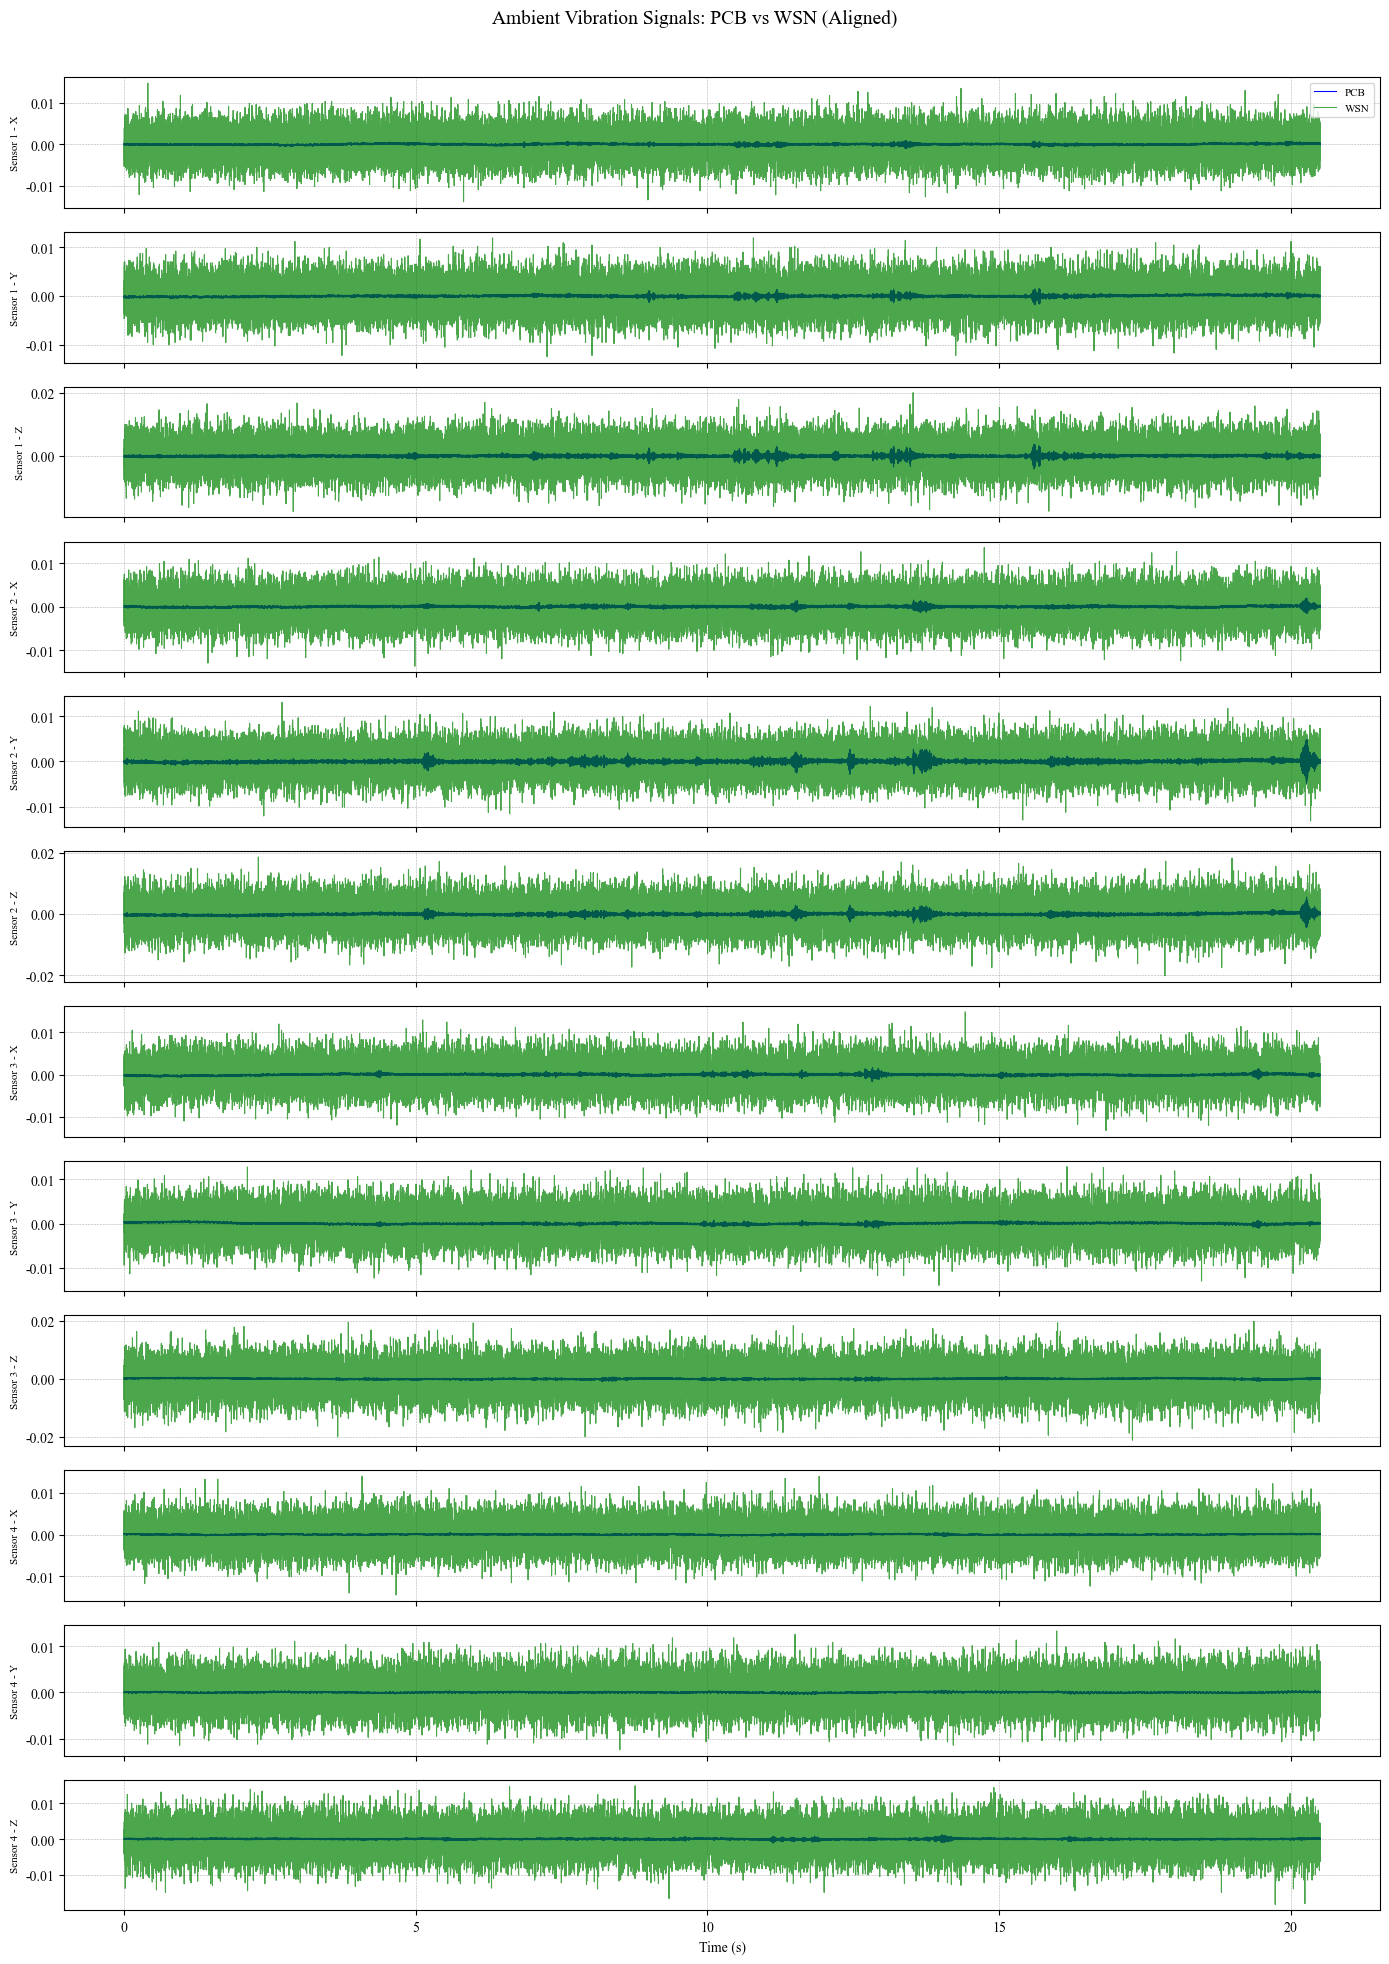

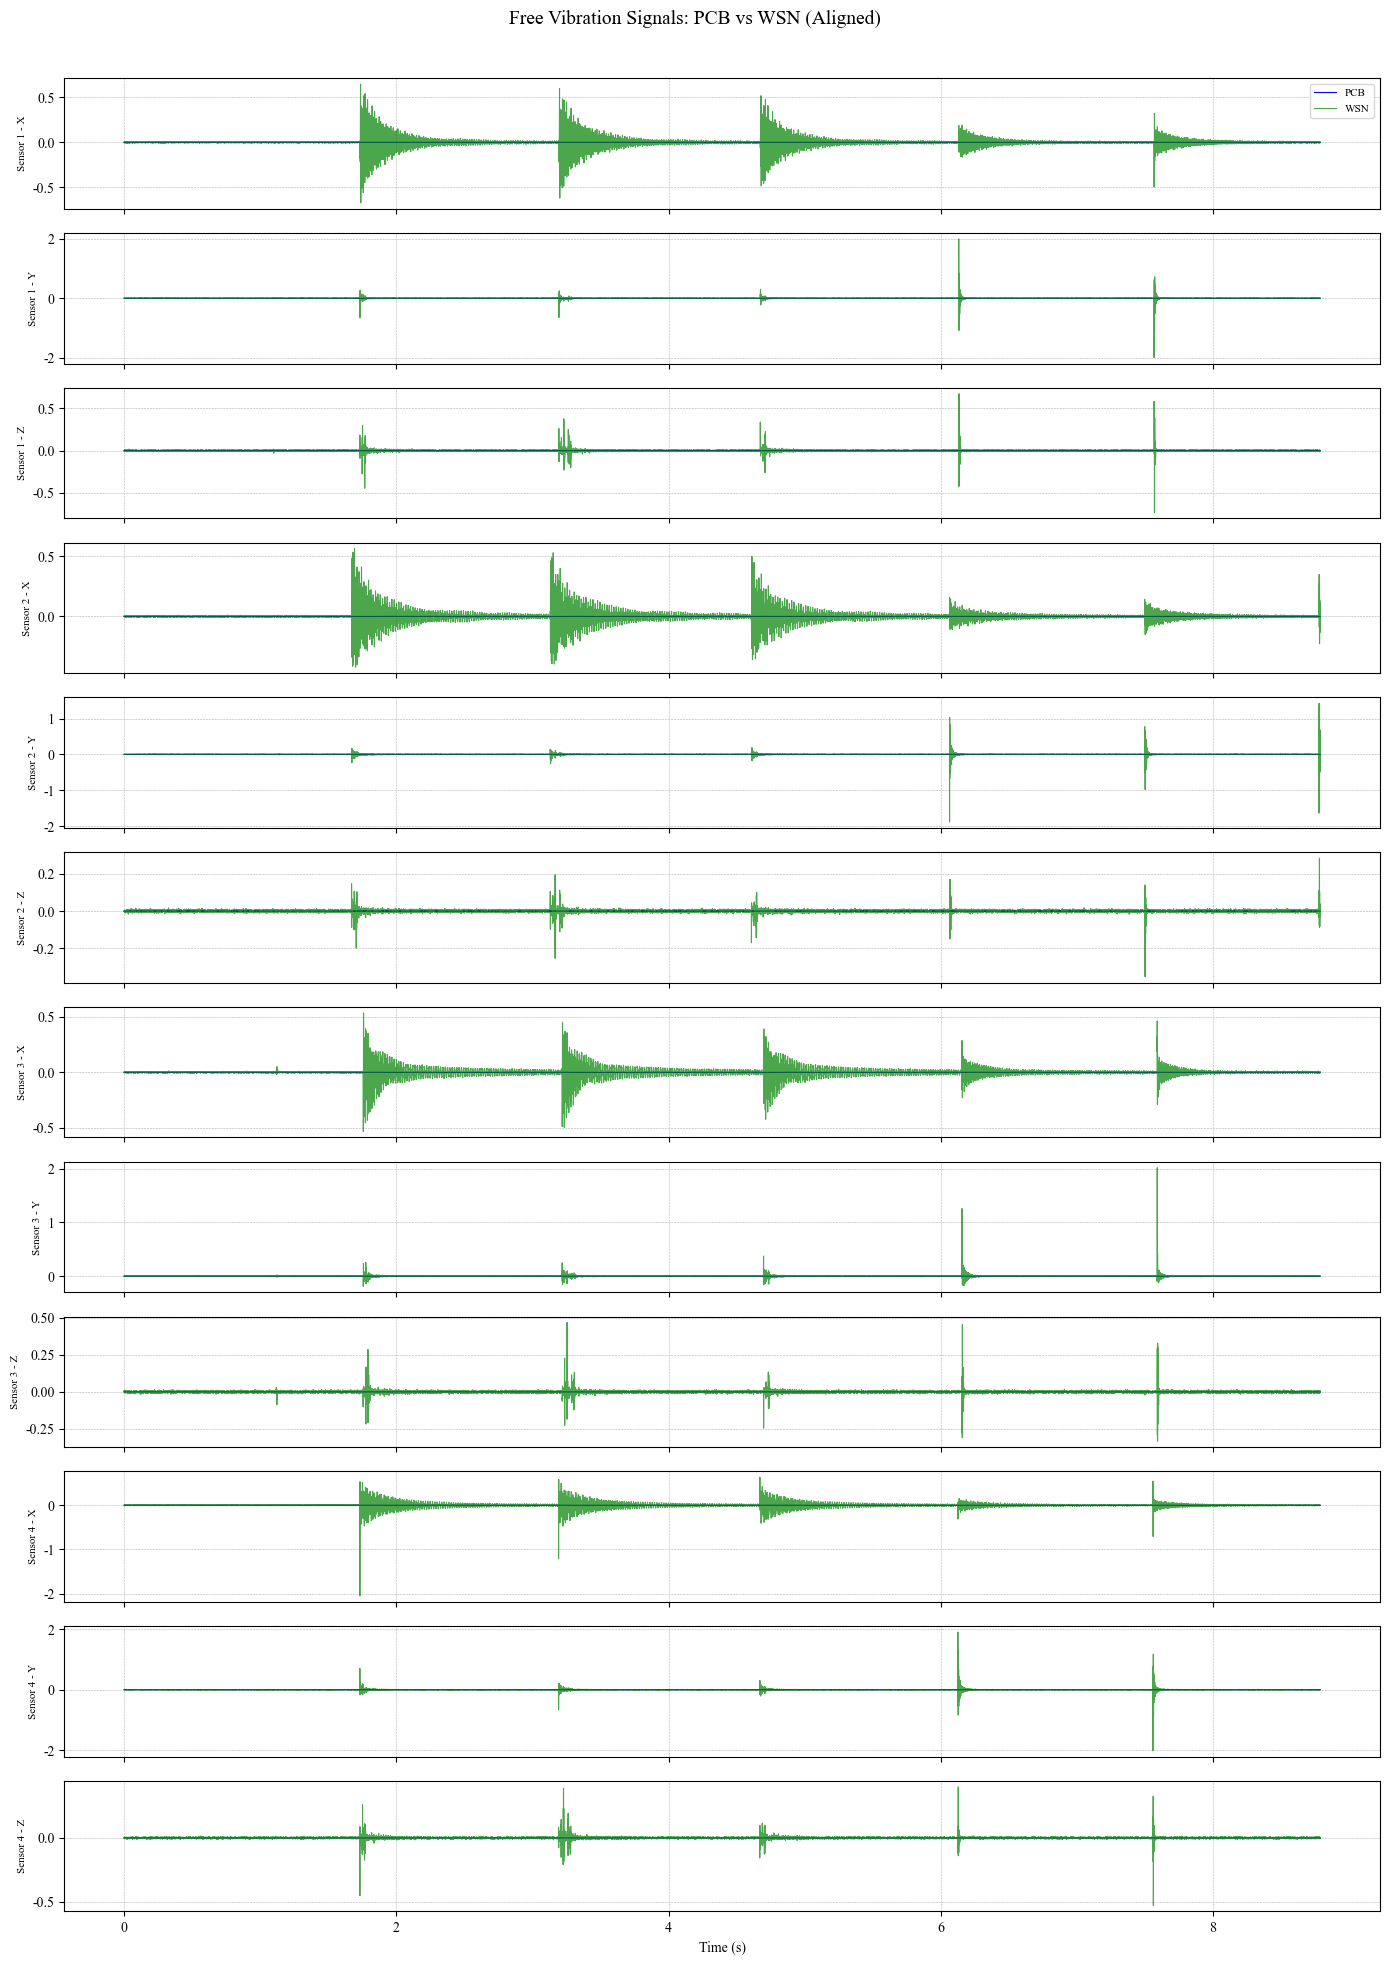

In [107]:
fs_pcb = 2048
fs_wsn = 100
fs_ratio = fs_pcb / fs_wsn

plot_aligned_signals(am_pcb_processed, am_wsn_processed, lag_ambient, fs_ratio, title_prefix="Ambient Vibration")
plot_aligned_signals(free_pcb_processed, free_wsn_processed, lag_free, fs_ratio, title_prefix="Free Vibration")


In [108]:
import matplotlib.pyplot as plt
import numpy as np

def plot_aligned_signals_normalized(pcb_data, wsn_data, lags, fs_ratio, title_prefix=""):
    """
    Plot PCB and WSN signals (already normalized) aligned based on lag (in WSN samples).
    - fs_ratio: PCB/WSN
    - lags: list of 4 lags (in WSN samples)
    """
    fig, axes = plt.subplots(12, 1, figsize=(14, 20), sharex=True)
    channel_labels = [
        "Sensor 1 - X", "Sensor 1 - Y", "Sensor 1 - Z",
        "Sensor 2 - X", "Sensor 2 - Y", "Sensor 2 - Z",
        "Sensor 3 - X", "Sensor 3 - Y", "Sensor 3 - Z",
        "Sensor 4 - X", "Sensor 4 - Y", "Sensor 4 - Z"
    ]

    for sensor_index in range(4):
        lag_lowrate = lags[sensor_index]
        lag_highrate = int(round(lag_lowrate * fs_ratio))

        for axis in range(3):
            ch = sensor_index * 3 + axis

            len_pcb_avail = len(pcb_data) - lag_highrate
            len_wsn_avail = len(wsn_data)
            min_len = min(len_pcb_avail, len_wsn_avail)

            pcb_trimmed = pcb_data[lag_highrate:lag_highrate + min_len, ch]
            wsn_trimmed = wsn_data[:min_len, ch]

            time = np.arange(min_len) / (fs_ratio * 100)  # In seconds

            axes[ch].plot(time, pcb_trimmed, label='PCB', color='blue', linewidth=0.8)
            axes[ch].plot(time, wsn_trimmed, label='WSN', color='green', linewidth=0.8, alpha=0.7)
            axes[ch].set_ylabel(channel_labels[ch], fontsize=8)
            axes[ch].grid(True, linestyle='--', linewidth=0.4)
            if ch == 0:
                axes[ch].legend(loc='upper right', fontsize=8)

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"{title_prefix} Aligned Signals (Normalized)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


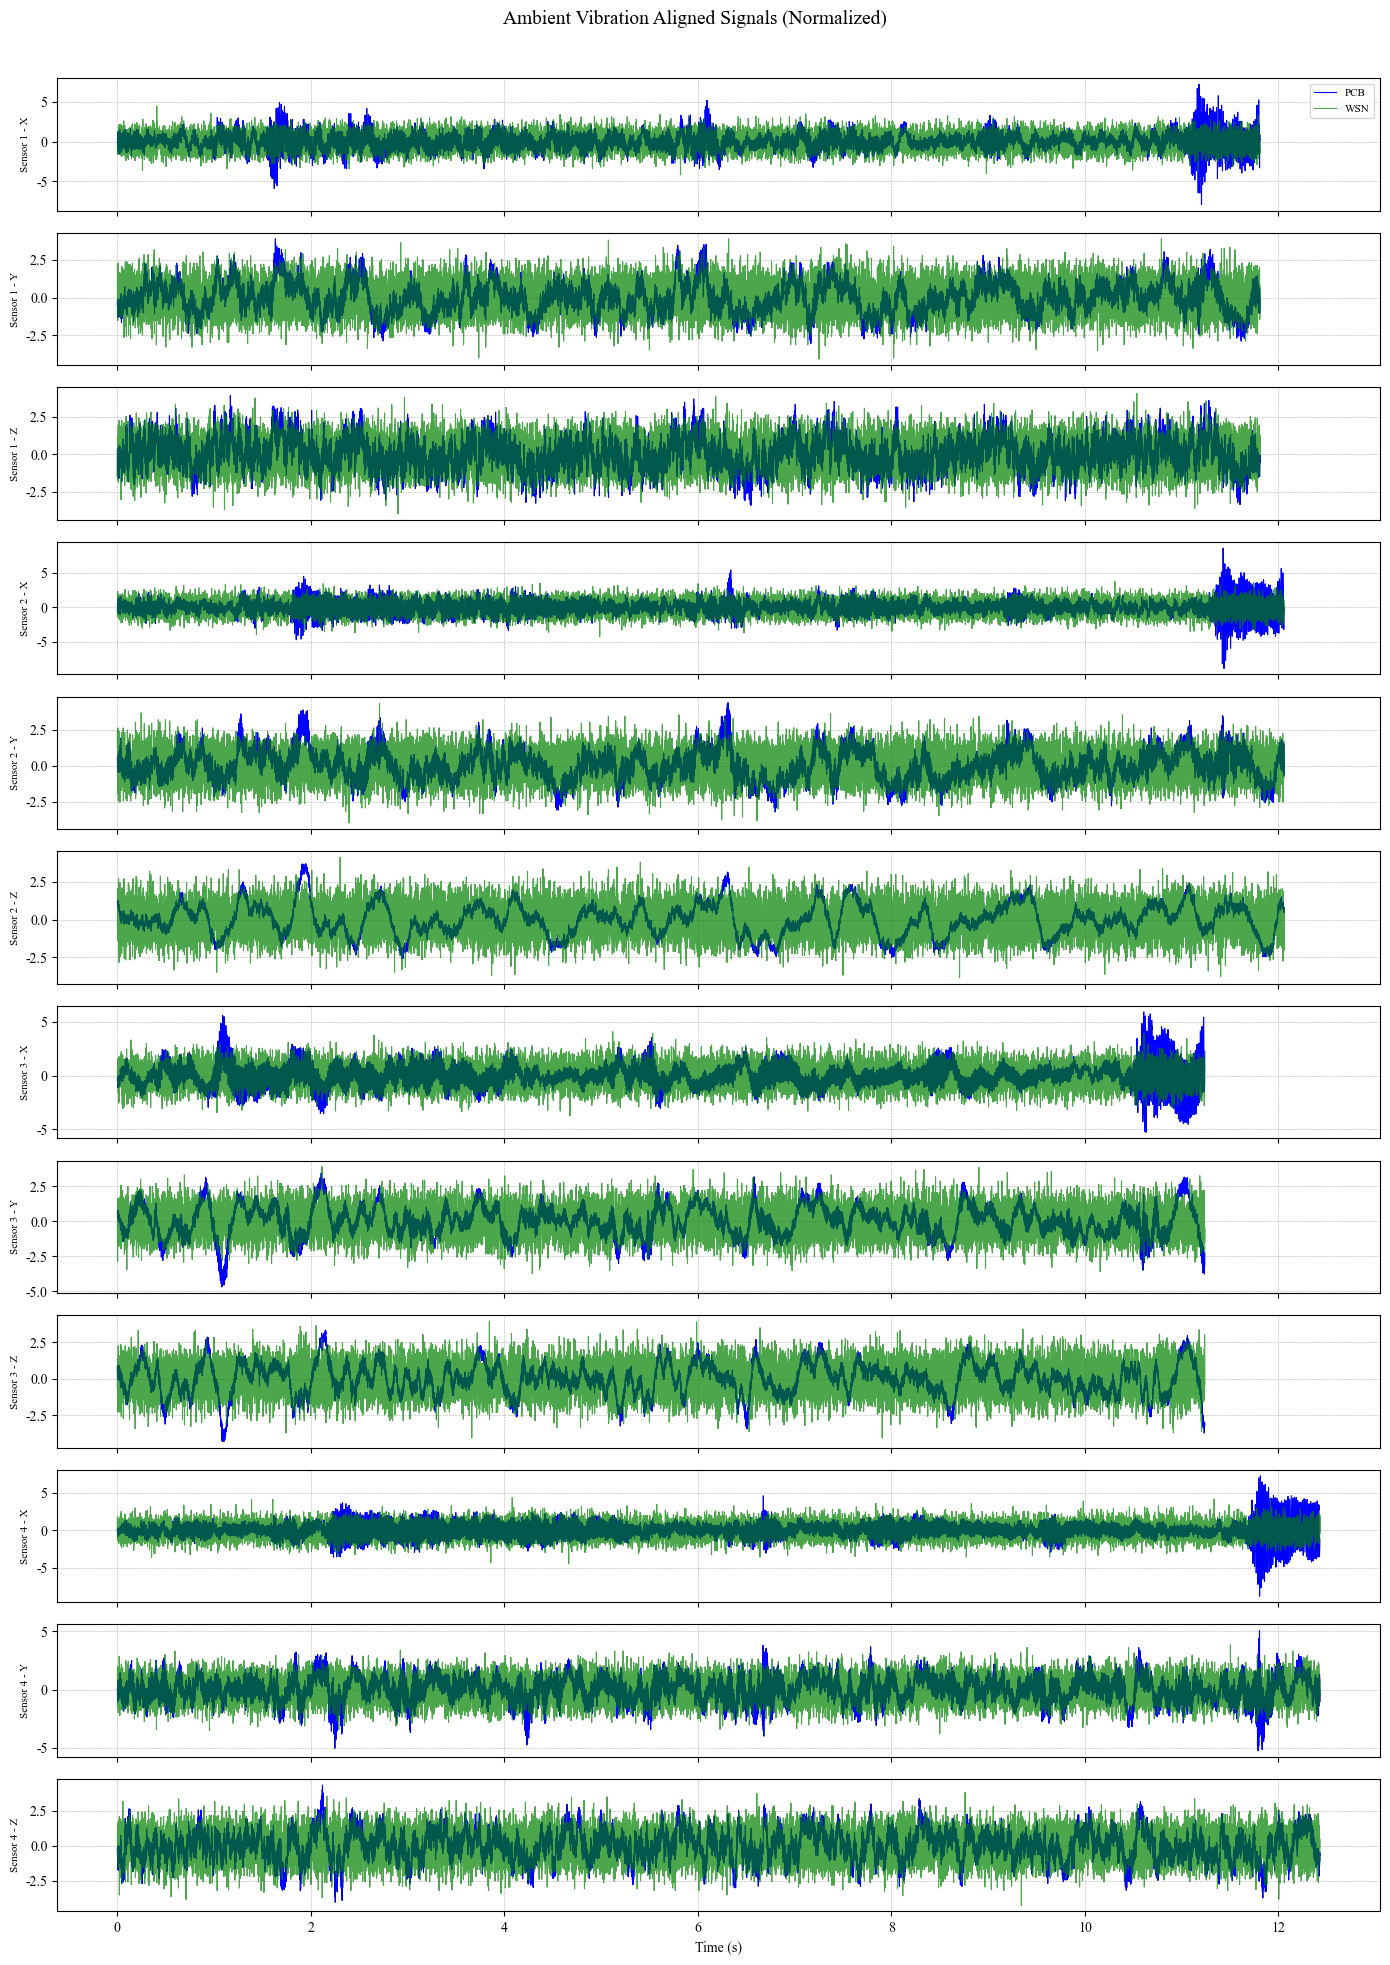

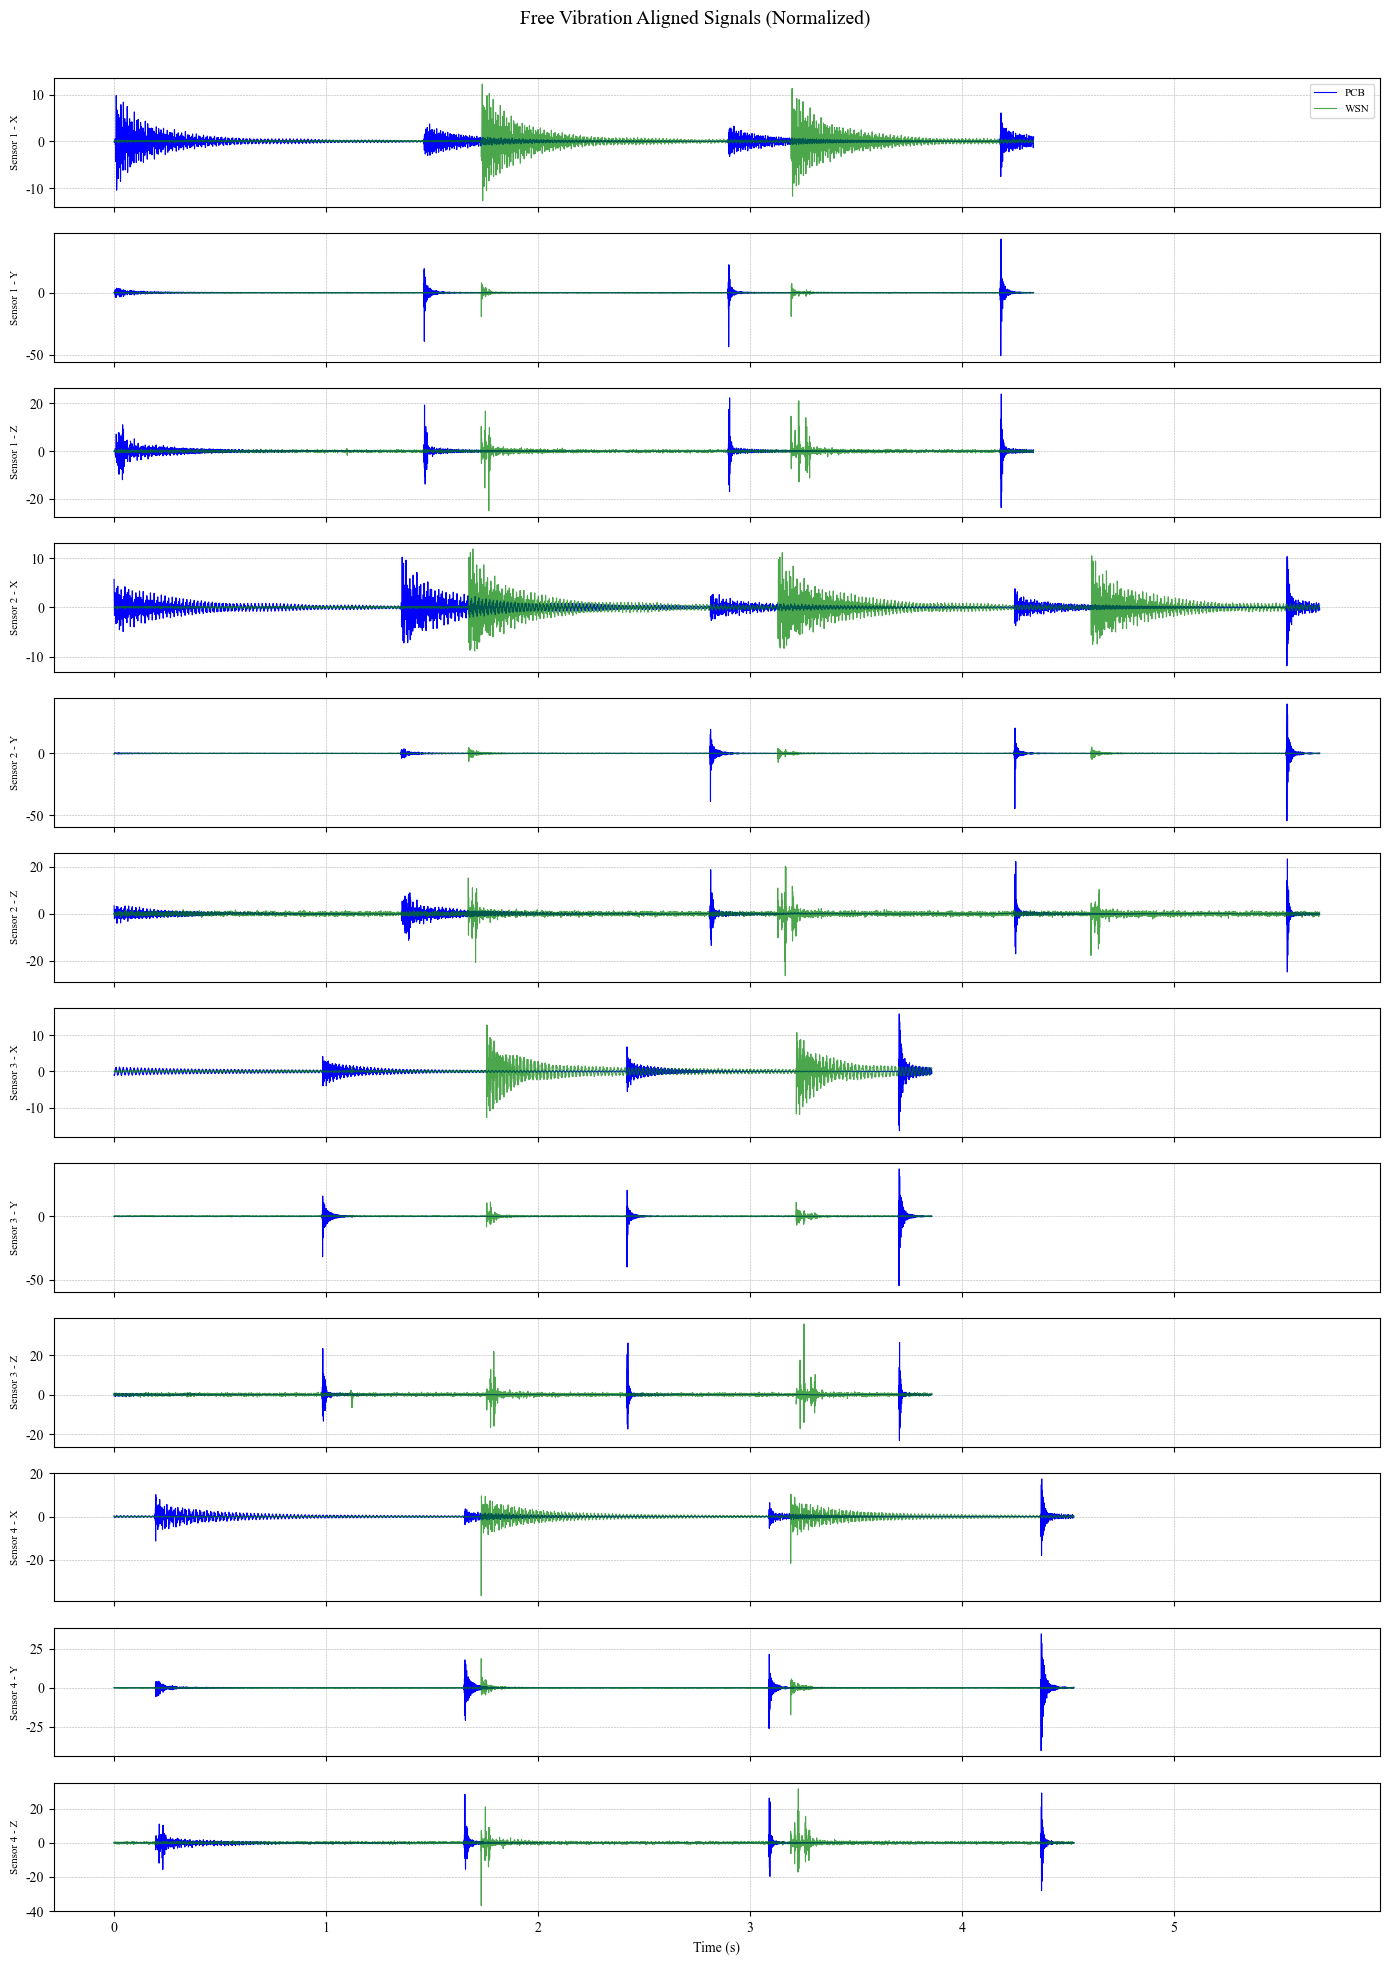

In [109]:
fs_pcb = 2048
fs_wsn = 100
fs_ratio = fs_pcb / fs_wsn

plot_aligned_signals_normalized(am_pcb_normalized, am_wsn_normalized, lag_ambient, fs_ratio, title_prefix="Ambient Vibration")
plot_aligned_signals_normalized(free_pcb_normalized, free_wsn_normalized, lag_free, fs_ratio, title_prefix="Free Vibration")
